In [153]:
# Load dataset
import pandas as pd
df = pd.read_csv("final_dataset.csv")

In [154]:
# Check dataset size (rows, columns)
df.shape

(7082, 10)

In [155]:
# Preview first rows
df.head()

,activity_final,type_final,species_final,age_final,injury_final,final_date,country,state,location,sex
0,surfing,unprovoked,white shark,39.0,injured,2026-03-18,usa,california,big river beach mendocino county,M
1,swimming,unprovoked,other shark,NaN,injured,2026-03-14,australia,western australia,exmouth,F
2,other,unprovoked,white shark,NaN,other,2026-03-10,australia,western australia,exmouth,M
3,diving,unprovoked,other,NaN,injured,2026-03-05,australia,queensland,lady elliott island,M
4,other,unprovoked,bull shark,55.0,other,2026-02-22,new caledonia,noumea,anse vata near point magnin,M


In [156]:
# Inspect column types and missing values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7082 entries, 0 to 7081
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   activity_final  7082 non-null   str    
 1   type_final      7082 non-null   str    
 2   species_final   7082 non-null   str    
 3   age_final       3927 non-null   float64
 4   injury_final    7082 non-null   str    
 5   final_date      6139 non-null   str    
 6   country         7032 non-null   str    
 7   state           6594 non-null   str    
 8   location        6513 non-null   str    
 9   sex             6497 non-null   str    
dtypes: float64(1), str(9)
memory usage: 553.4 KB


In [157]:
# Convert date column to datetime
df["final_date"] = pd.to_datetime(df["final_date"], errors="coerce")

In [158]:
# Calculate share of valid dates
date_completeness = df["final_date"].notna().mean()

f"{date_completeness:.2%}"

'86.68%'

In [159]:
# Check if data meets minimum quality threshold (80%)
if date_completeness >= 0.8:
    print("Sufficient date coverage for analysis")
else:
    print("Low date coverage")

Sufficient date coverage for analysis


### Data Quality Check
Approximately XX% of the records contain valid date information, exceeding the 80% threshold.  
This indicates that the dataset is sufficiently complete for time-based analysis.

In [160]:
# Extract year for easier filtering
df["year"] = df["final_date"].dt.year

In [161]:
# Check year distribution
df["year"].describe()

count    6139.000000
mean     1977.703861
std        44.156022
min      1640.000000
25%      1957.000000
50%      1994.000000
75%      2012.000000
max      2026.000000
Name: year, dtype: float64

In [162]:
# Filter dataset to include only recent data (year >= 2000)
df_recent = df[df["year"] >= 2000]

In [163]:
# Compare size before and after filtering
df.shape, df_recent.shape

((7082, 11), (2757, 11))

In [164]:
df_recent.isna().sum(axis=1).value_counts()

0    1925
1     654
2     145
3      29
4       4
Name: count, dtype: int64

### Data Completeness Check (Row-Level)
The majority of records have 0–1 missing values, suggesting minimal data loss when performing analysis on the filtered dataset.

# Insight:
# Older records were removed to focus on more recent and relevant data

In [165]:
# Top activities (what people were doing)
df_recent["activity_final"].value_counts().head(10)

activity_final
surfing     941
other       657
swimming    577
fishing     342
diving      240
Name: count, dtype: int64

In [166]:
# Top shark species
df_recent["species_final"].value_counts().head(10)

species_final
unknown        1092
other shark     896
white shark     303
tiger shark     189
bull shark      184
other            93
Name: count, dtype: int64

In [167]:
# Type of incidents
df_recent["type_final"].value_counts()

type_final
unprovoked    2184
other          356
provoked       217
Name: count, dtype: int64

In [168]:
# Injuries distribution
df_recent["injury_final"].value_counts()

injury_final
injured      1632
other         483
no injury     400
fatal         234
unknown         8
Name: count, dtype: int64

# Insight:
# Identify most common activities, species, and incident types
# to understand key risk patterns in recent data

## Key Insights (Recent Data ≥ 2000)

- Most incidents occur during **surfing**, followed by swimming and fishing  
- A small number of shark species (e.g. white, tiger, bull) account for most known cases  
- A large share of incidents involve **unknown species**, indicating data limitations  
- The majority of incidents are **unprovoked**, suggesting unpredictable risk patterns  
- Most outcomes are **non-fatal injuries**, but fatal cases still represent a significant risk  
- Filtering to recent data (≥ 2000) improves relevance for modern risk and business analysis

In [169]:
# Top countries with most incidents
df_recent["country"].value_counts().head(10)

country
usa              1327
australia         572
south africa      156
bahamas            81
brazil             66
new zealand        56
new caledonia      39
mexico             39
egypt              33
reunion            30
Name: count, dtype: int64

In [170]:
# Top states (more detailed hotspots)
df_recent["state"].value_counts().head(10)

state
florida                  679
new south wales          193
hawaii                   172
california               149
western australia        146
queensland               109
south carolina            94
north carolina            77
western cape province     57
eastern cape province     53
Name: count, dtype: int64

In [171]:
# Where do specific activities happen most?
pd.crosstab(df_recent["country"], df_recent["activity_final"])

activity_final,diving,fishing,other,surfing,swimming
country,,,,,
antigua,0,0,0,0,1
argentina,0,0,1,0,0
aruba,0,0,1,0,0
atlantic ocean,0,0,4,0,0
australia,56,90,107,228,91
...,...,...,...,...,...
usa,53,91,309,543,331
vanuatu,1,0,0,0,2
venezuela,0,1,0,2,1


In [172]:
# Get top 5 countries
top_countries = df_recent["country"].value_counts().head(5).index

# Crosstab only for top countries
pd.crosstab(
    df_recent[df_recent["country"].isin(top_countries)]["country"],
    df_recent["activity_final"]
)

activity_final,diving,fishing,other,surfing,swimming
country,,,,,
australia,56,90,107,228,91
bahamas,22,26,23,2,8
brazil,1,3,15,18,29
south africa,12,24,44,61,15
usa,53,91,309,543,331


## Activity by Location Insights

- Surfing and swimming dominate in high-incident countries such as the USA and Australia  
- The USA shows particularly high counts in both surfing and swimming, indicating mass participation risk  
- Australia has a more diverse activity distribution, including fishing and other activities  
- Smaller countries show lower volumes, suggesting more localized or niche risk patterns  
- Risk patterns vary significantly depending on the combination of location and activity

In [173]:
# Relationship between activity and injury severity
pd.crosstab(df_recent["activity_final"], df_recent["injury_final"])

injury_final,fatal,injured,no injury,other,unknown
activity_final,,,,,
diving,37,148,17,38,0
fishing,21,214,61,46,0
other,60,327,145,119,6
surfing,56,552,172,161,0
swimming,60,391,5,119,2


## Risk Profiling Insights (Activity vs Injury)

- Surfing has the highest number of incidents, but most cases result in non-fatal injuries  
- Swimming shows a comparatively higher proportion of fatal outcomes, indicating elevated risk per incident  
- Fishing presents a moderate risk profile, with a mix of injuries and non-injury outcomes  
- Diving has fewer incidents overall, but still includes a notable number of severe cases  
- Risk is not only driven by frequency, but also by the severity of outcomes across activities  

## Hypothesis Validation

**H1: Shark incidents are geographically concentrated**  
✔ Confirmed  
- Incidents are heavily concentrated in countries like the USA and Australia  
- Clear hotspots such as Florida and New South Wales were identified  

**H2: Certain activities are associated with higher risk**  
✔ Confirmed  
- Surfing accounts for the highest number of incidents  
- Swimming and fishing also contribute significantly  

**H3: Risk varies by severity across activities**  
✔ Confirmed  
- Swimming shows a relatively higher proportion of fatal outcomes  
- Surfing has high frequency but mostly non-fatal injuries  

**Overall Insight:**  
Risk is driven by a combination of location, activity, and severity — not just frequency alone  

In [174]:
# Import visualization libraries
import seaborn as sns
import matplotlib.pyplot as plt

In [175]:
# Set a clean visual style
sns.set_theme()

In [176]:
# Get the most common activities in recent data
top_activities = df_recent["activity_final"].value_counts().head(10)

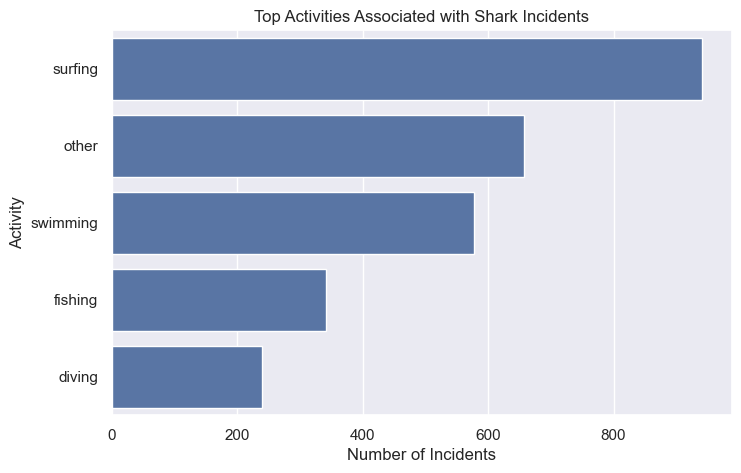

In [177]:
# Create bar plot for top activities
plt.figure(figsize=(8, 5))
sns.barplot(x=top_activities.values, y=top_activities.index)
plt.title("Top Activities Associated with Shark Incidents")
plt.xlabel("Number of Incidents")
plt.ylabel("Activity")

plt.show()

### Visualization Insight
Surfing and swimming are the most common activities associated with shark incidents in recent data.

In [178]:
# Get top 10 countries
top_countries = df_recent["country"].value_counts().head(10)

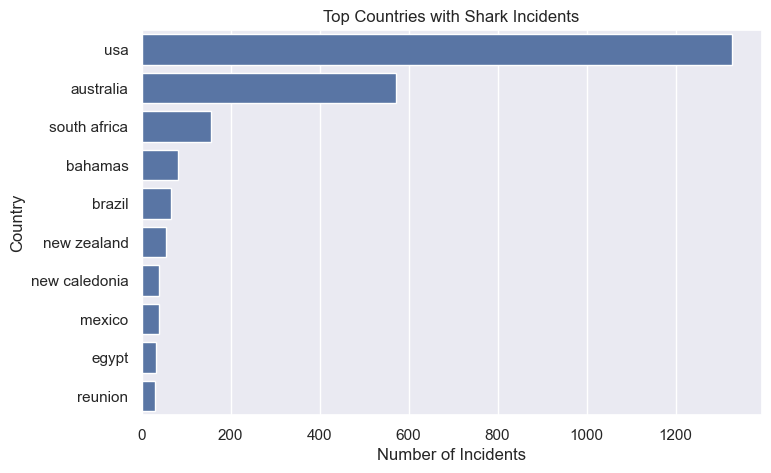

In [179]:
# Create bar plot for top countries
plt.figure(figsize=(8, 5))

sns.barplot(x=top_countries.values, y=top_countries.index)

plt.title("Top Countries with Shark Incidents")
plt.xlabel("Number of Incidents")
plt.ylabel("Country")

plt.show()

### Visualization Insight
Shark incidents are highly concentrated in a small number of countries, particularly the USA and Australia, indicating clear geographic hotspots.

In [180]:
# Create a crosstab for activity and injury
activity_injury = pd.crosstab(df_recent["activity_final"], df_recent["injury_final"])

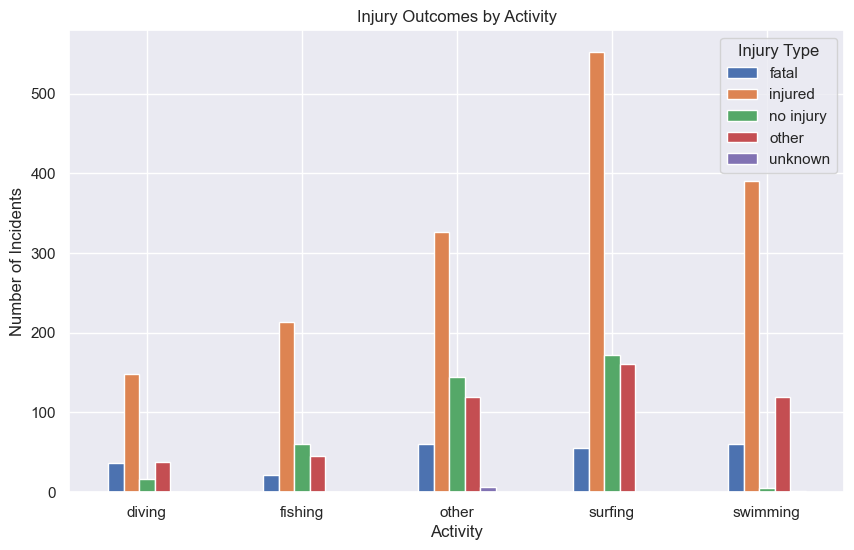

In [181]:
# Plot activity vs injury as grouped bar chart
activity_injury.plot(kind="bar", figsize=(10, 6))

plt.title("Injury Outcomes by Activity")
plt.xlabel("Activity")
plt.ylabel("Number of Incidents")
plt.legend(title="Injury Type")
plt.xticks(rotation=0)

plt.show()

### Visualization Insight
Different activities show different risk profiles. Surfing has the highest number of incidents overall, while swimming shows a comparatively higher share of severe outcomes.

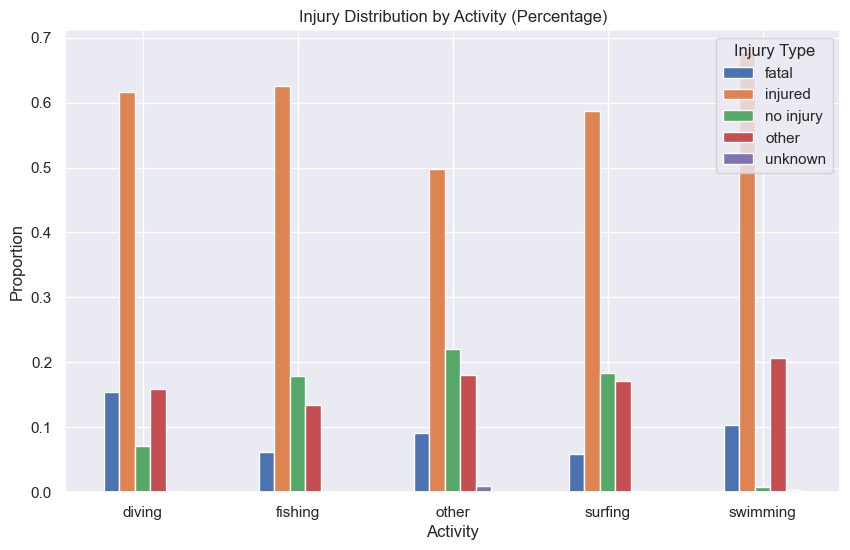

In [182]:
# Normalize to percentages
activity_injury_pct = activity_injury.div(activity_injury.sum(axis=1), axis=0)

activity_injury_pct.plot(kind="bar", figsize=(10,6))

plt.title("Injury Distribution by Activity (Percentage)")
plt.xlabel("Activity")
plt.ylabel("Proportion")
plt.legend(title="Injury Type")
plt.xticks(rotation=0)

plt.show()

### Visualization Insight
When normalized, some activities show a higher relative risk of severe outcomes, even if total incident counts are lower.